In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [166]:
gff = pd.read_csv('/scratch/gpfs/ziyangc/PASA/BulkRNASeq3/analysis/input/PA14_gff.csv', index_col=0)
gff.set_index('locus_tag', inplace=True)
# gff.head()

In [96]:
# # filename = '../output/PA14+SA/PA14/kallisto/umitools/counts_unfiltered/adata.h5ad'
# # filename = '../af_workdir/PA14+SA_PA14/af_quant/alevin/quants.h5ad'
# # filename = '../af_workdir/PA14+SA_PA14_umi/af_quant/alevin/quants.h5ad' # better
# # filename = '../af_workdir/PA14+SA_PA14_umi_no_piscem/af_quant/alevin/quants.h5ad'
# # filename = '../af_workdir/PA14+SA_PA14_737K/af_quant/alevin/quants.h5ad'
# # filename = '../output/PA14+SA/PA14/kallisto/737K/counts_unfiltered/adata.h5ad'
# filename = '/scratch/gpfs/ziyangc/PASA/ScRNAseq/new/output/kallisto_combination/PA14_index/v1/PA14+SA/counts_unfiltered/adata.h5ad'
# filename = '/scratch/gpfs/ziyangc/PASA/ScRNAseq/old/kallisto_out/CO_PA/counts_unfiltered/adata.h5ad'
f1 = '../output/kallisto_combination/PA14_index/v1/PA14+SA/counts_unfiltered/adata.h5ad'
f2 = '../output/kallisto_combination/PA14_index/v1/PA14+BC/counts_unfiltered/adata.h5ad'
f3 = '../output/kallisto_combination/PA14_index/v1/PAO1+SA/counts_unfiltered/adata.h5ad'
f4 = '../output/kallisto_combination/PA14_index/v1/PAO1+BC/counts_unfiltered/adata.h5ad'
f5 = '../output/kallisto_combination/PA14_index/v2/PA14+SA/counts_unfiltered/adata.h5ad'
f6 = '../output/kallisto_combination/PA14_index/v2/PAO1+SA/counts_unfiltered/adata.h5ad'
f7 = '../output/kallisto_combination/PA14_index/v2/PA14+BC/counts_unfiltered/adata.h5ad'
f8 = '../output/kallisto_combination/PA14_index/v2/PAO1+BC/counts_unfiltered/adata.h5ad'
adata1 = sc.read_h5ad(f1)
adata2 = sc.read_h5ad(f2)
adata3 = sc.read_h5ad(f3)
adata4 = sc.read_h5ad(f4)
adata5 = sc.read_h5ad(f5)
adata6 = sc.read_h5ad(f6)
adata7 = sc.read_h5ad(f7)
adata8 = sc.read_h5ad(f8)
print(adata1.shape, adata2.shape, adata3.shape, adata4.shape, adata5.shape, adata6.shape, adata7.shape, adata8.shape)

(82644, 5977) (103486, 5977) (70202, 5977) (124227, 5977) (85127, 5977) (110265, 5977) (90323, 5977) (114596, 5977)


In [173]:
adatax = ad.concat([adata5, adata6], join='outer')
adatay = ad.concat([adata7, adata8], join='outer')
adata = ad.concat([adatax, adatay], join='outer', label="condition", keys=['SA', 'BC'])
sc.pp.calculate_qc_metrics(adata, inplace=True, log1p=True)

/home/ziyangc/.conda/envs/scseq/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/ziyangc/.conda/envs/scseq/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/ziyangc/.conda/envs/scseq/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [174]:
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=3)
adata.obs['condition'].value_counts()

/home/ziyangc/.conda/envs/scseq/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/ziyangc/.conda/envs/scseq/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


condition
BC    6986
SA    4498
Name: count, dtype: int64

In [175]:
adata.layers["counts"] = adata.X.copy()
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

sc.tl.pca(adata)

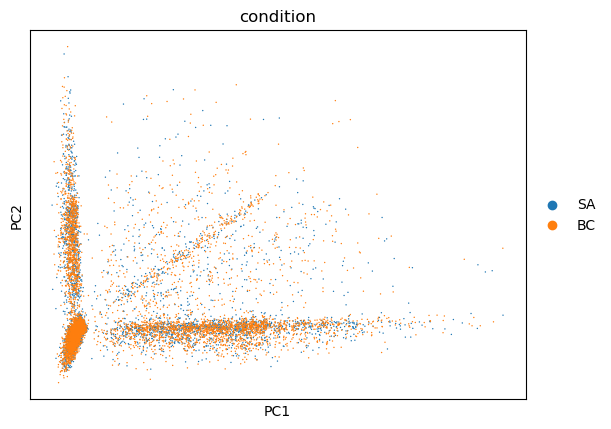

In [176]:
sc.pl.pca(
    adata,
    color=["condition"],
    dimensions=[(0, 1)],
    ncols=1,
    size=4,
)

In [177]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

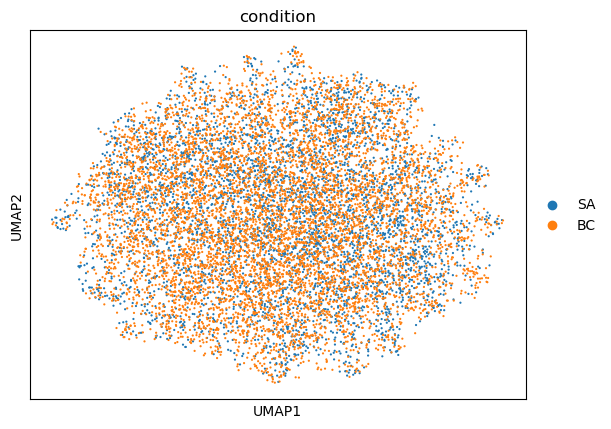

In [178]:
sc.pl.umap(
    adata,
    color="condition",
    # Setting a smaller point size to get prevent overlap
    size=10,
)

In [124]:
goi = ['PA14_36310', 'PA14_51430', 'PA14_44340', 'PA14_44350', 'PA14_44360', 'PA14_68300']
# goi = ['PA14_60470', 'PA14_49380', 'PA14_44010', 'PA14_14100', 'PA14_68440', 'PA14_65350', 'PA14_68300', 'PA14_44340', 'PA14_68360', 'PA14_71640', 'PA14_62130', 'PA14_68340', 'PA14_66260', ]
# goi = ['PA14_44350','PA14_30320','PA14_60700','PA14_49460','PA14_09150','PA14_36310','PA14_43850','PA14_67810','PA14_04920','PA14_64110','PA14_07770']

In [53]:
# sc.pl.umap(adata, color=goi)

In [179]:
adata_sa = adata[adata.obs['condition'] == 'SA'].copy()
adata_bc = adata[adata.obs['condition'] == 'BC'].copy()

/home/ziyangc/.conda/envs/scseq/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


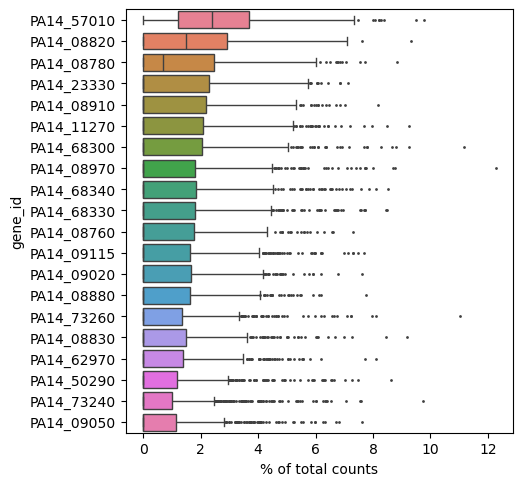

In [158]:
sc.pl.highest_expr_genes(adata, n_top=20)

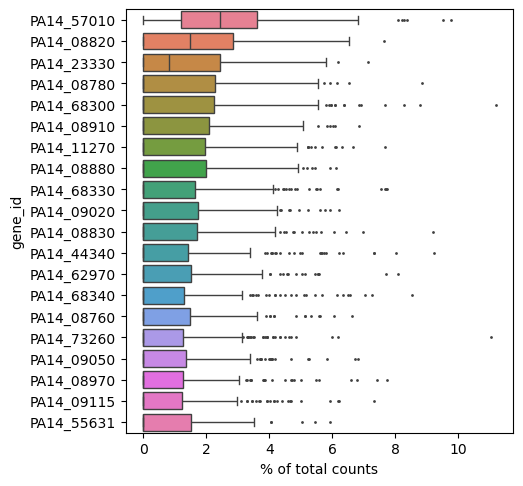

In [160]:
sc.pl.highest_expr_genes(adata_sa, n_top=20)

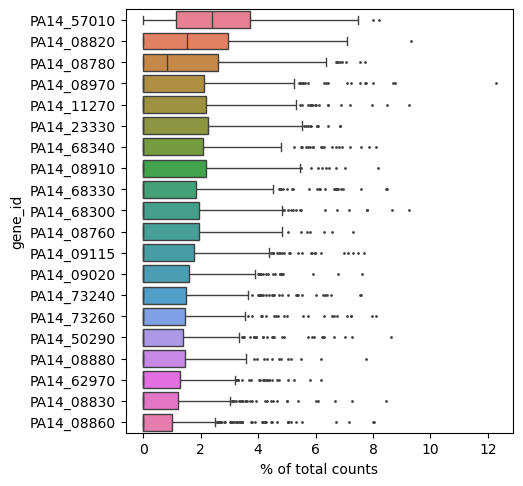

In [161]:
sc.pl.highest_expr_genes(adata_bc, n_top=20)

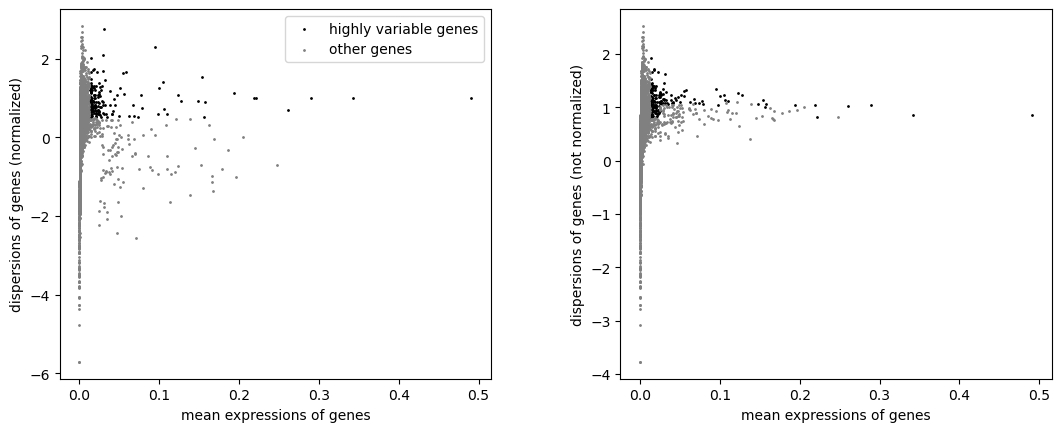

In [180]:
sc.pp.highly_variable_genes(adata_sa)
sc.pl.highly_variable_genes(adata_sa)

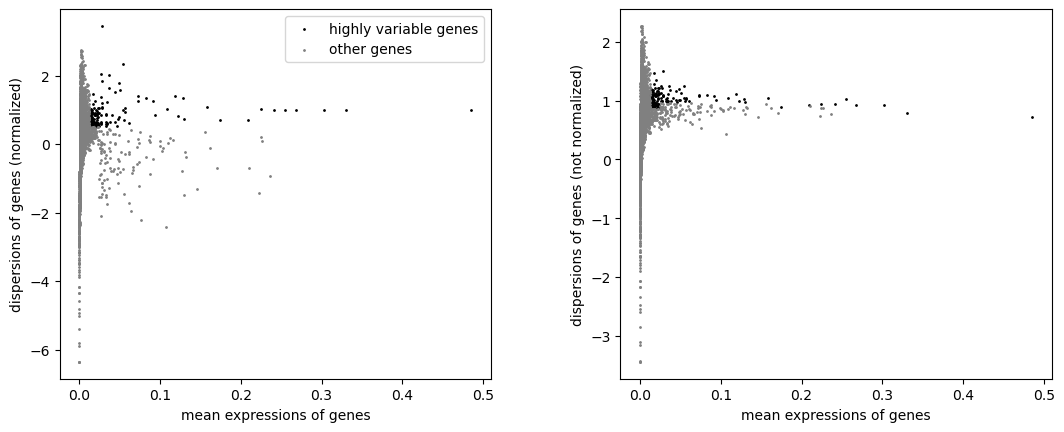

In [181]:
sc.pp.highly_variable_genes(adata_bc)
sc.pl.highly_variable_genes(adata_bc)

In [182]:
vsa=adata_sa.var.index[adata_sa.var['highly_variable']]
vbc=adata_bc.var.index[adata_bc.var['highly_variable']]

In [183]:
len(set(vbc).difference(set(vsa)))

82

In [184]:
gff['product'].loc[list(set(vbc).difference(set(vsa)))]

locus_tag
PA14_67600                          glutamine synthetase
PA14_01020                conserved hypothetical protein
PA14_30280                       thioredoxin reductase 1
PA14_43900                conserved hypothetical protein
PA14_44290                         aconitate hydratase 1
                                 ...                    
PA14_25080    fatty-acid oxidation complex alpha-subunit
PA14_17930            glycerol-3-phosphate dehydrogenase
PA14_17290                                  CTP synthase
PA14_30180            monomeric isocitrate dehydrogenase
PA14_73280                      ATP synthase delta chain
Name: product, Length: 82, dtype: object

In [186]:
print(gff['product'].loc[list(set(vsa).difference(set(vbc)))])

locus_tag
PA14_08910                30S ribosomal protein S3
PA14_14650    protein-export membrane protein SecF
PA14_66790                 heat shock protein HslU
PA14_60190                            clpB protein
PA14_71650                 aspartate ammonia-lyase
                              ...                 
PA14_18740              argininosuccinate synthase
PA14_63090                 L-lactate dehydrogenase
PA14_66170           putative carbamoyltransferase
PA14_44030     succinate dehydrogenase (A subunit)
PA14_51750                            TolQ protein
Name: product, Length: 106, dtype: object


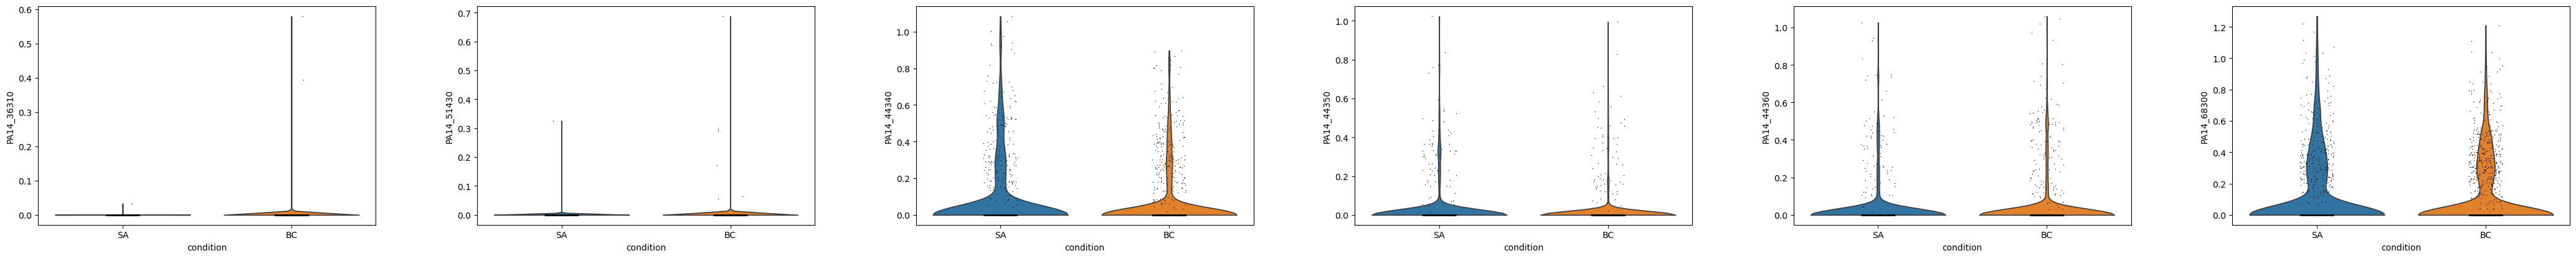

In [59]:
sc.pl.violin(adata, goi, groupby='condition')

In [ ]:
import csv

In [ ]:
with open('PA14SA_V1.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    # writer.writerow(fields)     # Write header
    writer.writerow(adata.var.index.values)   

In [ ]:
adata.var.to_csv('PA14SA_old.csv')